<div class="alert alert-block alert-success">
  <h1 style="color: #2e7d32; text-align: center; margin-bottom: 0px;"><b>
    📦 Supply Chain Delivery & Profitability Analysis
  </h1></b>
  <p style="text-align: center; color: #1b5e20; font-weight: bold; margin-top: 5px;">
    End-to-End Operational Delay Driver & Financial Impact Assessment
  </p>
</div>

<div class="alert alert-block alert-success">
<h2>Business Problem</h2>
    A global e-commerce company operating across multiple regions manages end-to-end order fulfillment, including shipping and delivery, for products like sporting goods. The company is facing inconsistent delivery performance, where actual shipping times often deviate from scheduled timelines, leading to late deliveries and unpredictable order profitability.
<h2>Desired Outcome:</h2>
    The goal is to analyze delivery operations, identify bottlenecks,optimize shipping decisions, and improve overall profitability and efficiency.

</div>

<div class="alert alert-block alert-success">
<h2>1. Environment Setup & Library Imports</h2>
Imports essential Python libraries: <code>pandas</code> and <code>numpy</code> for data manipulation, along with <code>matplotlib.pyplot</code> and <code>seaborn</code> for data visualization.
</div>

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


<div class="alert alert-block alert-success">
<h2>2. Loading Dataset & Initial Data Inspection</h2>
Loads <code>supply_chain_dataset.csv</code> using <code>latin-1</code> encoding to handle special characters, then previews column names, structural metadata, head/tail records, dimensions, duplicate count, and top missing value counts.
</div>

In [93]:
df = pd.read_csv('supply_chain_dataset.csv', encoding = 'latin-1')

In [94]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [95]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

In [96]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [97]:
df.tail()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class
180518,PAYMENT,4,4,168.949997,383.980011,Shipping on time,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 18:54,Standard Class


In [98]:
print('rows, columns :', df.shape)
print('\ncolumns:')
print(df.columns.tolist())
print('\nNum Duplicates:',df.duplicated().sum())
print('\nMissing Values (top20):')
print(df.isna().sum().sort_values(ascending=False).head(20))


rows, columns : (180519, 53)

columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Pr

<div class="alert alert-block alert-success">
<h2>3. Column Equivalence & Feature Distribution Check</h2>
Compares <code>Benefit per order</code> against <code>Order Profit Per Order</code> to verify redundant calculations and checks frequency counts for <code>Product Status</code>.
</div>

In [99]:
(df['Benefit per order']==df['Order Profit Per Order']).value_counts()

True    180519
Name: count, dtype: int64

In [100]:
df['Product Status'].value_counts()

Product Status
0    180519
Name: count, dtype: int64

<div class="alert alert-block alert-success">
<h2>4. Data Cleaning & Feature Selection</h2>
Removes redundant metadata, PII, location fields, and ID columns. Filters out canceled orders (<code>Delivery Status != 'Shipping canceled'</code>) and converts order/shipping dates into standard datetime objects.
</div>

In [101]:
columns_to_drop=['Product Description','Product Image','Customer Email','Customer Password','Customer Fname','Customer Lname','Customer Street',
                 'Customer Zipcode','Order Zipcode','Longitude','Latitude','Order Item Cardprod Id','Order Item Id','Order Item Discount',
                 'Order Item Discount Rate','Order Item Product Price','Order Item Quantity','Order Item Total','Category Id','Department Id',
                'Order Id','Order Customer Id','Customer Id','Product Card Id','Product Category Id','Benefit per order','Product Status',
                'Customer City','Order City','Order Country','Order State','Customer State','Market']
df = df.drop(columns=columns_to_drop)

In [102]:
df = df[df['Delivery Status'] != 'Shipping canceled']

In [103]:
for c in ['order date (DateOrders)','shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c],errors='coerce',dayfirst=False)

<div class="alert alert-block alert-success">
<h2>5. Post-Cleaning Structure & Missing Values Check</h2>
Displays the updated DataFrame shape, verifies top remaining missing values, and previews the cleaned records.
</div>

In [104]:
print('rows, columns :', df.shape)
print('\nMissing value(top5):')
print(df.isna().sum().sort_values(ascending=False).head(5))

rows, columns : (172765, 20)

Missing value(top5):
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
dtype: int64


In [105]:
df.head()


,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


<div class="alert alert-block alert-success">
<h2>6. Low-Cardinality Value Distribution Inspection</h2>
Iterates through all remaining dataset columns to identify categorical features with fewer than 10 unique values and prints their value counts.
</div>

In [106]:
for col in df.columns:
    if df[col].nunique()<10:
        print(f'\n{col} value_counts:')
        print(df[col].value_counts())


Type value_counts:
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) value_counts:
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

Days for shipment (scheduled) value_counts:
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

Delivery Status value_counts:
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

Late_delivery_risk value_counts:
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Customer Country value_counts:
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Customer Segment value_counts:
Customer Segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64

Order Status value_counts:
Order Status
COMPLETE  

<div class="alert alert-block alert-success">
<h2>7. Delay & Temporal Feature Engineering</h2>
Calculates actual shipping processing time, delay relative to scheduled duration, a boolean <code>Is_Delayed</code> flag, and extracts month, day name, and hour from order timestamps.
</div>

In [107]:
df['Order Processing Time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days
df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']
df['Is_Delayed'] = df['Delay']>0
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day'] = df['order date (DateOrders)'].dt.day_name()
df['order_hour'] = df['order date (DateOrders)'].dt.hour
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-12 15:25:39.457991,0.120801,203.828493,22.032360,141.278595,2016-06-16 03:25:14.452927,3.472816,0.539716,6.235511,11.482604
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 18:01:00,0.080000,119.980003,7.030000,50.000000,2015-09-25 08:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 08:11:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 03:38:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 21:08:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 08:00:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,0.466610,132.392520,104.355313,139.862956,NaN,1.670187,1.494150,3.405593,6.927276


<div class="alert alert-block alert-success">
<h2>8. Summary Statistics & Delay Frequency</h2>
Generates descriptive summary statistics for numerical features and checks the total count of delayed vs. non-delayed orders.
</div>

In [108]:
df['Is_Delayed'].value_counts()

Is_Delayed
True     94523
False    78242
Name: count, dtype: int64

In [109]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order Processing Time', 'Delay', 'Is_Delayed',
       'order_month', 'order_day', 'order_hour'],
      dtype='str')

In [110]:
df['Order Profit Per Order']

0          91.250000
1        -249.089996
2        -247.779999
3          22.860001
4         134.210007
             ...    
180514     40.000000
180515   -613.770019
180516    141.110001
180517    186.229996
180518    168.949997
Name: Order Profit Per Order, Length: 172765, dtype: float64

<div class="alert alert-block alert-success">
<h2>9. Order Profitability Categorization</h2>
Creates a <code>Profitability Flag</code> feature using <code>np.where</code> to categorize orders into <b>Profit</b> (> 0), <b>Loss</b> (< 0), or <b>Break_even</b> (= 0).
</div>

In [111]:
df['Order Profit Per Order']>0

0          True
1         False
2         False
3          True
4          True
          ...  
180514     True
180515    False
180516     True
180517     True
180518     True
Name: Order Profit Per Order, Length: 172765, dtype: bool

In [112]:
df['Profitability FLag'] = np.where(df['Order Profit Per Order']>0, 'Profit', np.where(df['Order Profit Per Order']<0, 'Loss', 'Break_even'))
df['Profitability FLag'].value_counts()

Profitability FLag
Profit        139354
Loss           32295
Break_even      1116
Name: count, dtype: int64

In [113]:
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

<div class="alert alert-block alert-success">
<h2>10. Visualizing Profitability Distribution</h2>
Configures custom plotting styles using the <code>viridis</code> color scheme and displays a pie chart showing percentage distributions of profitable, loss-making, and break-even orders.
</div>

In [114]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

viridis_colors = cm.viridis(np.linspace(0, 1, 5))
primary_color = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color = viridis_colors[2]
danger_color = '#900000'
neutral_color = viridis_colors[4]
custom_palette = viridis_colors

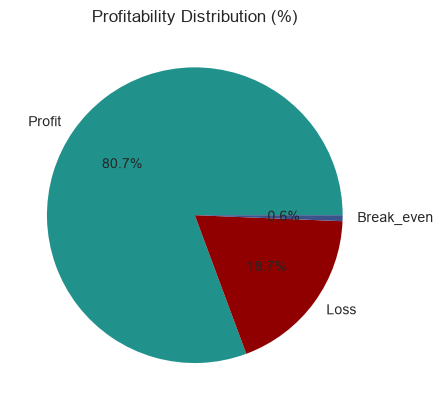

In [115]:
profit_counts = df['Profitability FLag'].value_counts(normalize=True) * 100
profit_counts.plot(kind='pie', autopct='%1.1f%%', colors=[accent_color, danger_color, secondary_color])
plt.ylabel('')
plt.title('Profitability Distribution (%)')
plt.show()

<div class="alert alert-block alert-success">
<h2>11. Executive Business KPIs Calculation</h2>
Calculates key metrics including total orders, late delivery volume, 90th percentile delay duration (P90), delivery success rates, total revenue profit, and financial loss linked to delays.
</div>

In [116]:
def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'
delayed_df= df[df['Delay']>0]
metrics = {}
metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['90% DElay (days)'] = delayed_df['Delay'].quantile(0.90)
metrics['On time Delivery %'] = (1 - float(metrics['Late Deliveries']) / metrics['Total Orders']) * 100
metrics['Late Delivery %'] = float(metrics['Late Deliveries']) / metrics['Total Orders'] * 100
metrics['Total Profit'] = format_func(df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum())
metrics['Total Loss due to delays'] = format_func(df.loc[df['Delay'] > 0, 'Order Profit Per Order'].sum())

print('\n--- Business KPIs ---\n')
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")


--- Business KPIs ---

Total Orders: 172765
Late Deliveries: 94523
90% DElay (days): 3.00
On time Delivery %: 45.29
Late Delivery %: 54.71
Total Profit: 7.5M $
Total Loss due to delays: 2.1M $


<div class="alert alert-block alert-success">
<h2>12. Profit Aggregation by Delay Days</h2>
Groups orders by exact delay days to compute mean profit, total profit, and order count for each delay duration.
</div>

In [117]:
profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order']
      .agg(
          mean_profit='mean',
          total_profit='sum',
          order_count='count'
      )
       .reset_index()
)

In [118]:
profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2,23.360134,4.875961e+05,20873
1,-1,21.604769,4.476292e+05,20719
2,0,22.249118,8.154302e+05,36650
3,1,22.333227,1.194895e+06,53503
4,2,21.128491,5.821110e+05,27551
5,3,20.031412,1.356527e+05,6772
6,4,21.368783,1.431067e+05,6697


<div class="alert alert-block alert-success">
<h2>13. Delay Frequency Percentage Distribution</h2>
Calculates the normalized percentage breakdown of orders across different delay durations.
</div>

In [119]:
delay_distribution = (
    df['Delay']
    .value_counts(normalize=True)
    .sort_index() * 100
).reset_index()

In [120]:
delay_distribution

,Delay,proportion
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


<div class="alert alert-block alert-success">
<h2>14. Visualizing Delay Distribution & Profit Impact</h2>
Displays formatted metrics tables and plots a side-by-side figure: a delay percentage distribution bar chart and a dual-axis chart tracking total vs. mean profit across delay days.
</div>


 Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,order_count
0,-2,23.4,487596.1,20873
1,-1,21.6,447629.2,20719
2,0,22.2,815430.2,36650
3,1,22.3,1194894.7,53503
4,2,21.1,582111.0,27551
5,3,20.0,135652.7,6772
6,4,21.4,143106.7,6697



 Delay Distribution (%):


,Delay_Days,Percentage
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


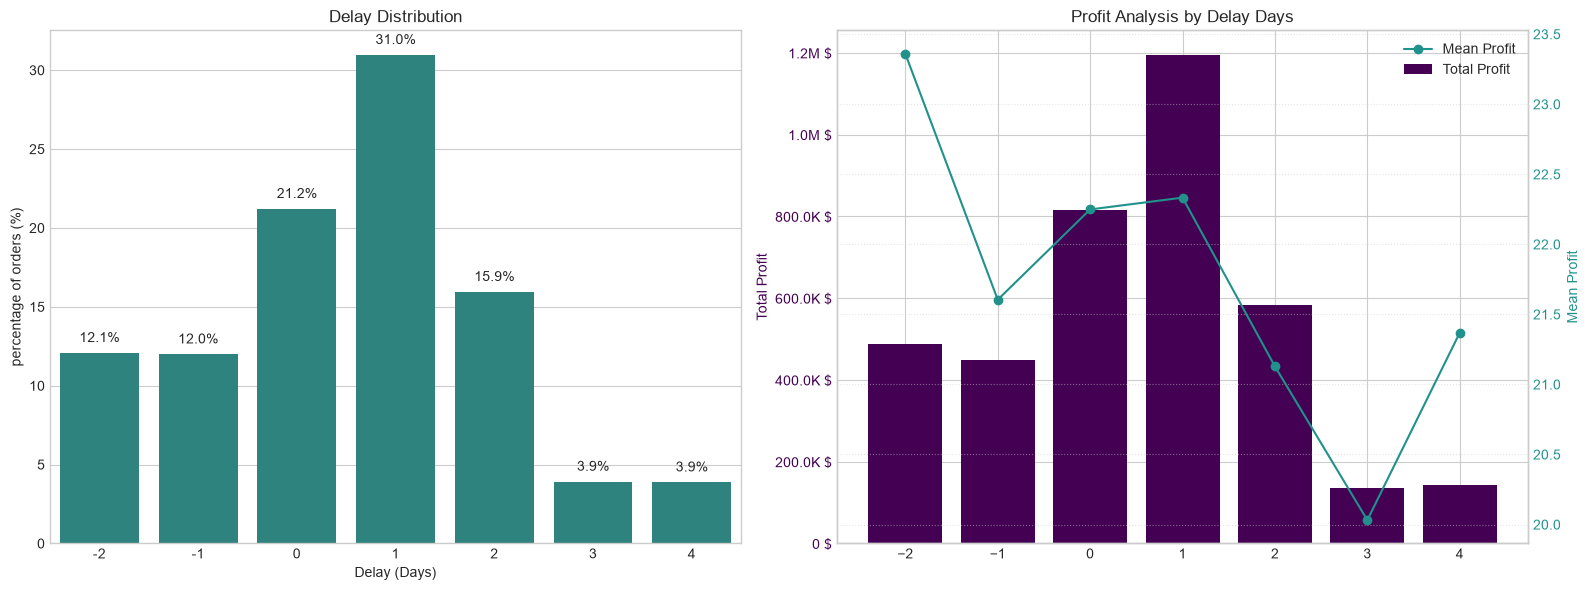

In [121]:
delay_distribution.columns = ['Delay_Days', 'Percentage']

print("\n Profit Metrics by Delay Day:")
display(profit_metrics.round(1))

print("\n Delay Distribution (%):")
display(delay_distribution)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='Delay_Days',y='Percentage', data=delay_distribution, color=accent_color, ax=ax1)
ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (Days)')
ax1.set_ylabel('percentage of orders (%)')

for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', ha='center', va='bottom')

ax2.set_ylabel("Total Profit", color=primary_color)
ax2.bar(profit_metrics['Delay'],profit_metrics['total_profit'], color=primary_color, label='Total Profit')
ax2.tick_params(axis='y', labelcolor=primary_color)

ax3 = ax2.twinx()

ax3.set_xlabel("Delay Days")
ax3.set_ylabel("Mean Profit", color=accent_color)
ax3.plot(profit_metrics['Delay'], profit_metrics['mean_profit'], marker='o', label='Mean Profit', color=accent_color)
ax3.tick_params(axis='y', labelcolor=accent_color)


def format_func(value,tick_number):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(format_func))

ax3.set_title("Profit Analysis by Delay Days")

lines, labels = ax3.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax3.legend(lines + lines2, labels + labels2, loc='upper right')
ax3.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

    

<div class="alert alert-block alert-success">
<h2>15. Categorical Delay Percentage Helper Function</h2>
Defines <code>compute_delay_pct_by_category()</code> to aggregate order counts, late orders, and compute late delivery percentages for any categorical column.
</div>

<div class="alert alert-block alert-success">
<h2>16. Multi-Dimensional Delay Breakdown Grid</h2>
Plots a 2x3 grid of horizontal bar charts visualizing delay percentages across Order Region, Customer Segment, Shipping Mode, Order Status, Payment Type, and Department Name.
</div>

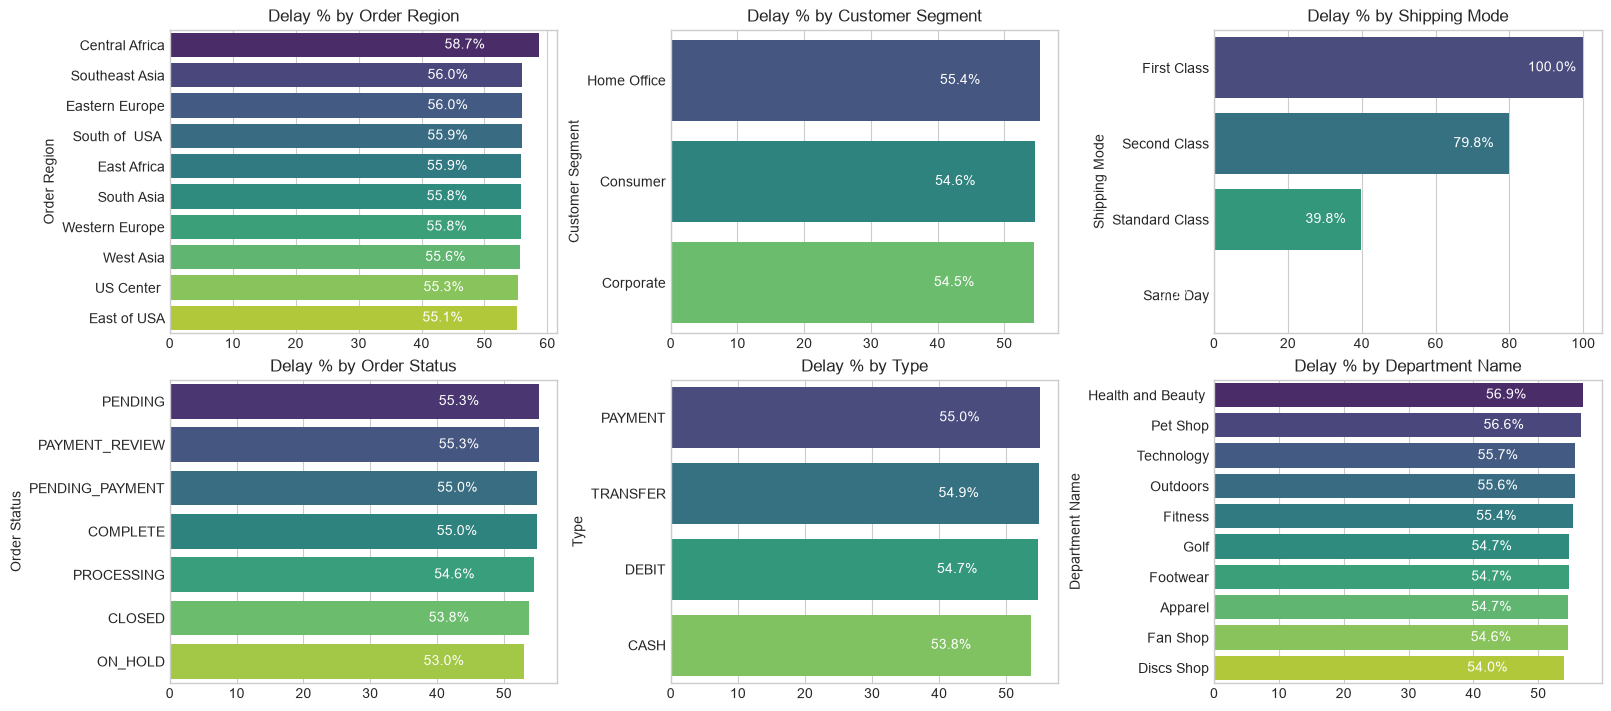

In [122]:
def compute_delay_pct_by_category (category):
    cat_df = df.groupby(category).agg(
        total_orders=('Delay', 'count'),
        late_orders=('Is_Delayed', 'sum')
    ).reset_index()
    cat_df ['delay_pct'] = cat_df ['late_orders'] / cat_df ['total_orders'] * 100
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10)
    return cat_df
    
categories = ['Order Region', 'Customer Segment', 'Shipping Mode', 'Order Status', 'Type', 'Department Name']

fig, axes = plt.subplots (2, 3, figsize=(16, 7), constrained_layout=True)
axes = axes.flatten()

for ax, category in zip(axes, categories):
    cat_df = compute_delay_pct_by_category(category)
    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        palette='viridis'
    )
    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('')
    ax.set_ylabel(category)
    for i, row in cat_df.reset_index().iterrows():
        ax.text(row['delay_pct'] - 15, i, f"{row['delay_pct']:.1f}%", va='center', fontsize=10, color = 'white')

plt.show()


<div class="alert alert-block alert-success">
<h2>17. Customer Segment Delay Inspection</h2>
Executes the helper function to inspect specific late delivery percentages and order volumes across customer segments.
</div>

In [123]:
compute_delay_pct_by_category('Customer Segment')

,Customer Segment,total_orders,late_orders,delay_pct
2,Home Office,30817,17060,55.359055
0,Consumer,89420,48855,54.635428
1,Corporate,52528,28608,54.462382


<div class="alert alert-block alert-success">
<h2>18. Regional Late Delivery Driver Analysis Function</h2>
Defines <code>top_drivers_for_region()</code> to evaluate factor levels (shipping mode, segment, department, type) causing late deliveries within a specified geographic region and plot top drivers.
</div>

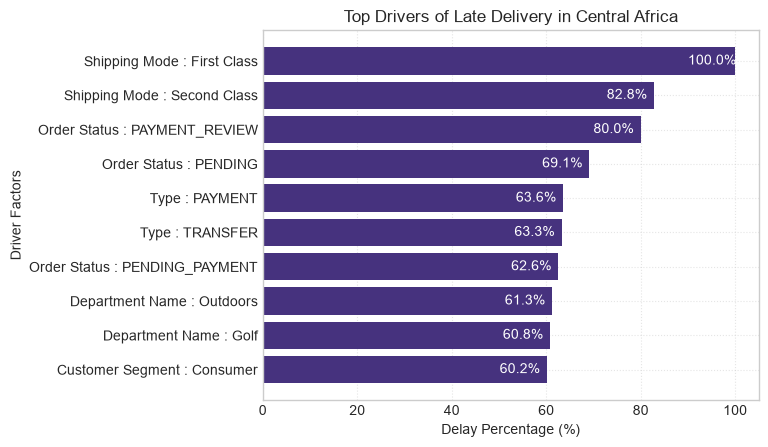

In [124]:
def top_drivers_for_region(region):
    df_region = df [df ['Order Region'] == region].copy()
    drivers = ['Shipping Mode', 'Customer Segment', 'Department Name', 'Type', 'Order Status']
    all_factors = []
    for factor in drivers:
        temp = (
            df_region.groupby (factor)
                .agg(
                    total_orders=('Delay', 'count'),
                    late_orders=('Is_Delayed', 'sum'),
                    avg_delay=('Delay', 'mean')
                )
                        .reset_index()
        )
        temp['delay_pct'] = temp ['late_orders'] / temp['total_orders'] * 100
        temp ['Driver'] = factor
        temp ['Factor_Level'] = factor + " : " + temp [factor].astype(str)
        
        all_factors.append(temp[['Driver', 'Factor_Level', 'delay_pct', 'avg_delay', 'total_orders']])
        
    final_df = pd.concat(all_factors)

    top_factors = final_df.sort_values('delay_pct', ascending=False).head(10)
    plt.figure()

    bars = plt.barh(top_factors ['Factor_Level'], top_factors['delay_pct'])

    plt.xlabel("Delay Percentage (%)")
    plt.ylabel("Driver Factors")
    plt.title(f"Top Drivers of Late Delivery in {region}")
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.gca().invert_yaxis()
    for bar in bars:
        width = bar.get_width()
        plt.text(width - 10, bar.get_y() + bar.get_height()/2,
                 f"{width:.1f}%",
                 va='center',fontsize = 10,color = 'white')

    plt.show()

top_drivers_for_region('Central Africa')

<div class="alert alert-block alert-success">
<h2>19. Regional Driver Analysis Execution</h2>
Calls <code>top_drivers_for_region()</code> for Central Africa and East Africa to isolate specific delay drivers in these regions.
</div>

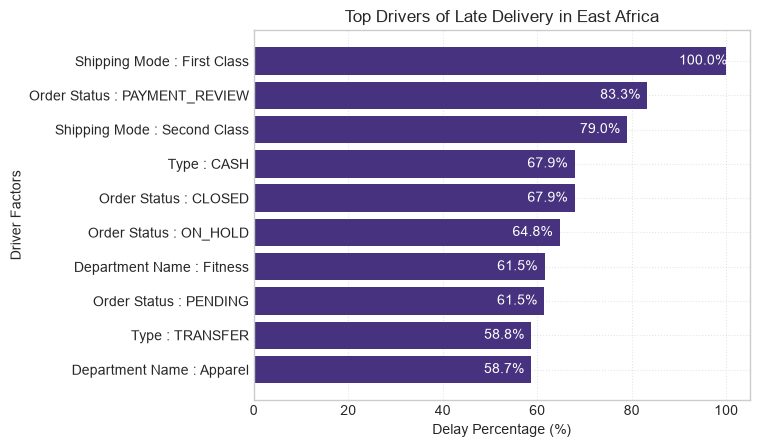

In [125]:
top_drivers_for_region('East Africa')

In [126]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,...,Product Price,shipping date (DateOrders),Shipping Mode,Order Processing Time,Delay,Is_Delayed,order_month,order_day,order_hour,Profitability FLag
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,...,327.750000,2018-02-03 22:56:00,Standard Class,3,-1,False,1,Wednesday,22,Profit
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,...,327.750000,2018-01-18 12:27:00,Standard Class,5,1,True,1,Saturday,12,Loss
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,...,327.750000,2018-01-17 12:06:00,Standard Class,4,0,False,1,Saturday,12,Loss
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,...,327.750000,2018-01-16 11:45:00,Standard Class,3,-1,False,1,Saturday,11,Profit
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,...,327.750000,2018-01-15 11:24:00,Standard Class,2,-2,False,1,Saturday,11,Profit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,399.980011,Shipping on time,0,Fishing,EE. UU.,Home Office,Fan Shop,...,399.980011,2016-01-20 03:40:00,Standard Class,4,0,False,1,Saturday,3,Profit
180515,DEBIT,3,2,395.980011,Late delivery,1,Fishing,EE. UU.,Corporate,Fan Shop,...,399.980011,2016-01-19 01:34:00,Second Class,3,1,True,1,Saturday,1,Loss
180516,TRANSFER,5,4,391.980011,Late delivery,1,Fishing,EE. UU.,Corporate,Fan Shop,...,399.980011,2016-01-20 21:00:00,Standard Class,5,1,True,1,Friday,21,Profit
180517,PAYMENT,3,4,387.980011,Advance shipping,0,Fishing,Puerto Rico,Consumer,Fan Shop,...,399.980011,2016-01-18 20:18:00,Standard Class,3,-1,False,1,Friday,20,Profit


<div class="alert alert-block alert-success">
<h2>20. Shipping Timeline Boundary Check</h2>
Inspects the minimum and maximum dates within the dataset to verify time horizons covered in the data.
</div>

In [127]:
df['shipping date (DateOrders)'].min()

Timestamp('2015-01-03 00:00:00')

In [128]:
df['shipping date (DateOrders)'].max()

Timestamp('2018-02-06 22:14:00')

<div class="alert alert-block alert-success">
<h2>21. Temporal Delay Aggregations (Month, Day, Hour)</h2>
Aggregates mean late delivery rates across order months, days of the week, and hours of the day.
</div>

In [129]:
delay_by_month = (
    df.groupby('order_month') ['Is_Delayed']
        .mean()
        .reset_index()
)
delay_by_month ['delay_pct'] = delay_by_month ['Is_Delayed'] * 100
delay_by_day = (
    df.groupby('order_day') ['Is_Delayed']
        .mean()
        .reset_index()
)
delay_by_day ['delay_pct'] = delay_by_day ['Is_Delayed'] * 100

delay_by_hour = (

    df.groupby('order_hour') ['Is_Delayed']
        .mean()
        .reset_index()
)
delay_by_hour ['delay_pct'] = delay_by_hour ['Is_Delayed'] * 100

<div class="alert alert-block alert-success">
<h2>22. Previewing Time-Based Aggregations</h2>
Displays the aggregated delay percentage tables for monthly, daily, and hourly periods.
</div>

In [130]:
delay_by_month

,order_month,Is_Delayed,delay_pct
0,1,0.542542,54.254150
1,2,0.546046,54.604550
2,3,0.548094,54.809390
3,4,0.545042,54.504230
4,5,0.549980,54.998022
5,6,0.547645,54.764535
6,7,0.537310,53.731048
7,8,0.553871,55.387128
8,9,0.553885,55.388454
9,10,0.540970,54.097044


In [131]:
delay_by_hour

,order_hour,Is_Delayed,delay_pct
0,0,0.540686,54.068641
1,1,0.554227,55.422680
2,2,0.551937,55.193735
3,3,0.541420,54.142012
4,4,0.536747,53.674683
5,5,0.552672,55.267154
6,6,0.528388,52.838802
7,7,0.549882,54.988239
8,8,0.531329,53.132903
9,9,0.543575,54.357480


In [132]:
delay_by_day

,order_day,Is_Delayed,delay_pct
0,Friday,0.544884,54.488442
1,Monday,0.555338,55.533838
2,Saturday,0.542619,54.261937
3,Sunday,0.551524,55.152418
4,Thursday,0.547202,54.720188
5,Tuesday,0.539841,53.984137
6,Wednesday,0.548452,54.845175


<div class="alert alert-block alert-success">
<h2>23. Visualizing Time-Based Delay Patterns</h2>
Generates a three-panel figure plotting monthly trends, day-of-week distributions, and hourly delay trends, complete with peak delay annotations.
</div>

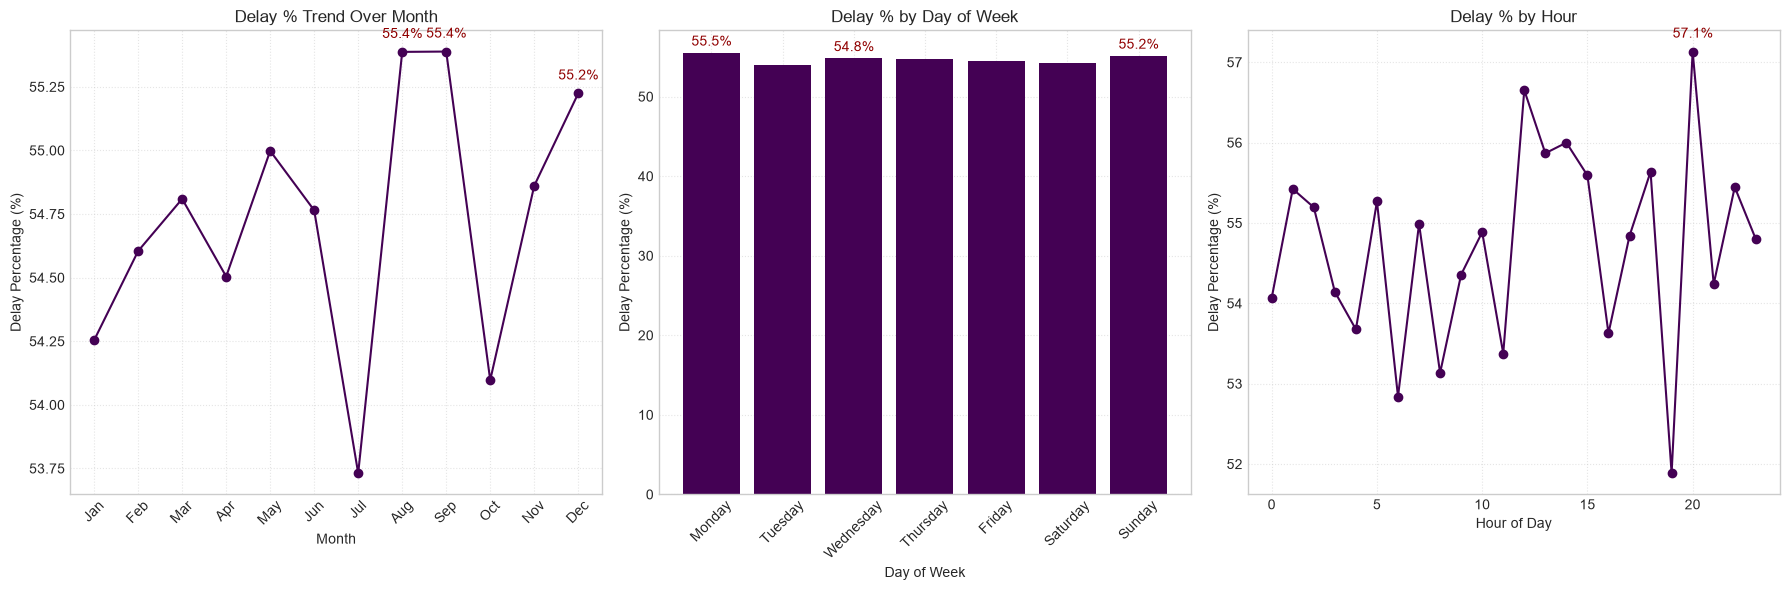

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [133]:

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

ax1.plot(delay_by_month ['order_month'], delay_by_month ['delay_pct'], marker='o', color=primary_color)
ax1.set_xticks (range(1,13))
ax1.set_xticklabels (['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")
ax1.set_title("Delay % Trend Over Month")
ax1.grid(True, linestyle=':', alpha=0.5)

top3_month = delay_by_month.nlargest (3, 'delay_pct')
for _, row in top3_month.iterrows():
    ax1.annotate(f"{row['delay_pct']:.1f}%", (row['order_month'], row['delay_pct']), textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, color=danger_color)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
delay_by_day ['order_day'] = pd.Categorical(delay_by_day['order_day'], categories=day_order, ordered=True)
delay_by_day = delay_by_day.sort_values('order_day')
ax2.bar(delay_by_day ['order_day'], delay_by_day ['delay_pct'], color = primary_color)
ax2.set_xticklabels (delay_by_day['order_day'], rotation=45)
ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Delay Percentage (%)")
ax2.set_title("Delay % by Day of Week")
ax2.grid(True, linestyle=':', alpha=0.5)


top3_day = delay_by_day.nlargest(3, 'delay_pct')
for _, row in top3_day.iterrows():
    height = row['delay_pct']
    ax2.text(row['order_day'], height + 0.5, f'{height:.1f}%', ha='center', va='bottom', fontsize=10, color=danger_color)


ax3.plot(delay_by_hour['order_hour'], delay_by_hour['delay_pct'], marker='o', color = primary_color)
ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Delay Percentage (%)")
ax3.set_title("Delay % by Hour")
ax3.grid(True, linestyle=':', alpha=0.5)

top3_hour = delay_by_hour.nlargest (3, 'delay_pct')
for _, row in top3_hour.iterrows():
    ax3.annotate(f"{row['delay_pct']:.1f}%", (row['order_hour'], row['delay_pct']),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, color=danger_color)
    plt.tight_layout()
    plt.show()

<div class="alert alert-block alert-success">
<h2>24. Conclusion </h2>
     This analysis has surfaced a clear and urgent picture: a global e-commerce operation where the majority of orders (54.71%) fail to meet their promised delivery windows, costing $2.1M in at-risk profit and undermining customer trust at scale.
The root causes are identifiable and addressable. Shipping mode misconfiguration (First Class at 100% late, Second Class at 79.8%) is the dominant operational failure. Payment processing friction creates a secondary bottleneck. Seasonal volume spikes are not adequately planned for. And geographic disparities, while present, are secondary to the systemic company-wide pattern.

</div>